#Mini Project: Breast Cancer Classification

Goal
Build ML models to:

    Predict breast cancer diagnosis
    Understand confusion matrix
    Calculate evaluation metrics
    Demonstrate overfitting

Dataset used:
load_breast_cancer() from scikit-learn

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# load Dataset

In [2]:
# Load dataset
data = load_breast_cancer()

# Features
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target
y = pd.Series(data.target)

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

# dataset information

In [3]:
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Classes:")
print(data.target_names)

print("\nClass Distribution:")
print(y.value_counts())

Feature Shape: (569, 30)
Target Shape : (569,)

Target Classes:
['malignant' 'benign']

Class Distribution:
1    357
0    212
Name: count, dtype: int64


# Train-Test split 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (455, 30)
Testing Data : (114, 30)


# Train Logistic Regression model 

In [5]:
# Create model
lr_model = LogisticRegression(max_iter=5000)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics

Evaluation metrics are calculated from the confusion matrix.

1. Accuracy
---> How often the model is correct.

Accuracy= (TP+TN)/(TP+TN+FP+FN)

Good when classes are balanced.

Problem:
If 95% of emails are non-spam, predicting “non-spam” always gives 95% accuracy but the model is useless.


2. Precision
---> Out of predicted positives, how many were actually positive?

Precision= TP/(TP+FP)

High precision means:
Few false positives.

Example:
Important in spam detection or fraud detection.


3. Recall
---> Out of actual positives, how many did the model catch?

Recall= TP/(TP+FN)


High recall means:
Few false negatives.

Example:
Disease detection. Missing a disease is dangerous.

4. F1 Score
---> Balance between precision and recall.

F1=2⋅ (Precision+Recall) / (Precision+Recall)


Useful when:
    classes are imbalanced
    both FP and FN matter

In [7]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.956140350877193
Precision: 0.9459459459459459
Recall   : 0.9859154929577465
F1 Score : 0.9655172413793104


# confusion matrix

A confusion matrix compares:

Actual values
Predicted values


For binary classification:

|                 | Predicted Positive  | Predicted Negative  |
| --------------- | ------------------- | ------------------- |
| Actual Positive | True Positive (TP)  | False Negative (FN) |
| Actual Negative | False Positive (FP) | True Negative (TN)  |



Meaning:


    TP → model correctly predicted positive
    TN → model correctly predicted negative
    FP → model predicted positive incorrectly
    FN → model missed a positive case

Example:
---> Spam email classifier

Spam predicted as spam → TP
Spam predicted as not spam → FN
Normal email predicted as spam → FP
Normal email predicted as normal → TN

In [8]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[39  4]
 [ 1 70]]


| Value | Meaning                       |
| ----- | ----------------------------- |
| 39    | Correct malignant predictions |
| 4     | False positives               |
| 1     | False negatives               |
| 70    | Correct benign predictions    |

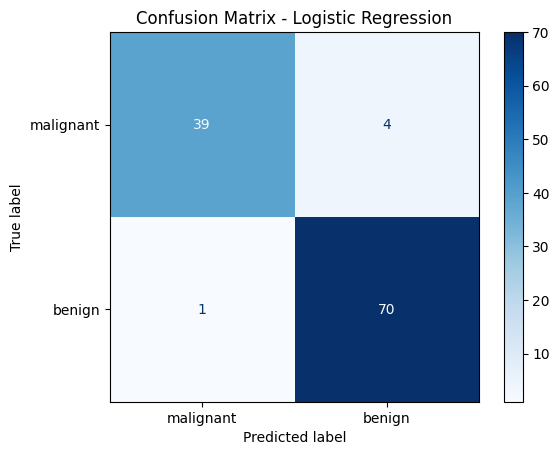

In [10]:
# visualize confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [11]:
# classification report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# now demonstrating overfitting using highly complex decison tree

In [12]:
tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
# compare train vs test accuracy

train_acc = tree_model.score(X_train, y_train)
test_acc = tree_model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 1.0
Testing Accuracy : 0.9473684210526315


Interpretation:


1. Model memorized training data
2. Poor generalization
3. This is overfitting

# Reduce overfitting 

Limit tree depth

# Overfitting

What is Overfitting?
--> The model memorizes training data instead of learning patterns.

Signs: 


    Very high training accuracy
    Low test accuracy

The model performs well on known data but poorly on unseen data.


| Situation    | Behavior                |
| ------------ | ----------------------- |
| Underfitting | Model too simple        |
| Good Fit     | Learns general patterns |
| Overfitting  | Memorizes noise/details |



Causes of Overfitting:


    Too much model complexity
    Small dataset
    Too many features
    Training too long
    Noise in data


Preventing Overfitting
1. More Data
    Usually the best solution.

 Train/Test Split
--> Evaluate on unseen data.

Common:

80/20 split
70/30 split



2. Cross Validation
    Split data multiple times for reliable evaluation.

3. Regularization
    Penalizes overly complex models.

Examples:

    L1 Regularization
    L2 Regularization


4. Dropout (Deep Learning)
    Randomly turns off neurons during training.


6. Early Stopping
    Stop training when validation performance stops improving.

In [14]:
small_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

small_tree.fit(X_train, y_train)

train_acc_small = small_tree.score(X_train, y_train)
test_acc_small = small_tree.score(X_test, y_test)

print("Training Accuracy:", train_acc_small)
print("Testing Accuracy :", test_acc_small)

Training Accuracy: 0.978021978021978
Testing Accuracy : 0.9473684210526315


Now:

- train accuracy decreases slightly
- test accuracy improves/stabilizes

This shows better generalization.

In [15]:
print("""
PROJECT CONCLUSION

1. Logistic Regression successfully classified breast cancer cases.

2. Confusion Matrix helped analyze correct and incorrect predictions.

3. Accuracy, Precision, Recall, and F1-score evaluated model performance.

4. Decision Tree with unlimited depth showed overfitting.

5. Reducing model complexity improved generalization.
""")


PROJECT CONCLUSION

1. Logistic Regression successfully classified breast cancer cases.

2. Confusion Matrix helped analyze correct and incorrect predictions.

3. Accuracy, Precision, Recall, and F1-score evaluated model performance.

4. Decision Tree with unlimited depth showed overfitting.

5. Reducing model complexity improved generalization.

